In [210]:
%load_ext autoreload
%autoreload 2

from functions import *
import pandas as pd
import pickle
import os
from datetime import datetime
from evaluate import *
from sklearn.covariance import ledoit_wolf

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
# ticker_list = ['REE', 'SAM', 'HAP', 'GMD', 'GIL', 'TMS', 'SAV', 'DHA', 'MHC', 'HAS'] # 10 stocks with the most observations
ticker_list = ['REE', 'SAM', 'HAP'] # 3 stocks with the most observations
limits = {
    'hose':0.07,
    'hnx':0.1,
    'upcom':0.15
}

# Parameters

horizon = 10
seq_len = 1000
train_pct = 0.958

# Read and merge into 1 dataset

if "stock_data.csv" in os.listdir("data"):
    merged_df = pd.read_csv(
        os.path.join("data", "stock_data.csv"),
        index_col=None
    ).assign(
        date = lambda df : pd.to_datetime(df["date"])
    )
else:
    # Read and merge data
    hnx = pd.read_csv(os.path.join("data", "CafeF.HNX.Upto31.07.2025.csv")).assign(
        floor = "hnx"
    )
    hsx = pd.read_csv(os.path.join("data", "CafeF.HSX.Upto31.07.2025.csv")).assign(
        floor = "hose"
    )
    upcom = pd.read_csv(os.path.join("data", "CafeF.UPCOM.Upto31.07.2025.csv")).assign(
        floor = "upcom"
    )
    indexes = pd.read_csv(os.path.join("data", "CafeF.INDEX.Upto06.08.2025.csv")).assign(
        floor = "index"
    )

    # Rename columns
    hnx, hsx, upcom, indexes = [
        df.rename(columns={
            "<Ticker>":"ticker",
            "<DTYYYYMMDD>":"date",
            "<Open>":"open",
            "<High>":"high",
            "<Low>":"low",
            "<Close>":"close",
            "<Volume>":"volume"
        }) for df in [hnx, hsx, upcom, indexes]
    ]
        
    # Merge and clean data
    # UPCOM has missing tickers for some reason
    merged_df = pd.concat(
        [hnx, hsx, upcom, indexes],
        axis=0
    ).reset_index(drop=True).dropna(subset="ticker")\
    .assign(
        date=lambda df : df["date"].astype(str).apply(lambda x: datetime.strptime(x, "%Y%m%d").date())
    )
    merged_df.to_csv(
        os.path.join("data", "stock_data.csv"),
        index=False
    ) # Save merged data to save time in future runs


# Data cleaning and merging

data = merged_df.sort_values(["ticker", "date"]).assign(
    returns = lambda df : df.groupby("ticker")["close"].pct_change(),
    log_returns_pct = lambda df : np.log(df["close"] / df.groupby("ticker")["close"].shift(1))*100
)

data = data.loc[data["ticker"].str.len()==3] # Eliminate ETF, and indeces

data["limit"] = data["floor"].map(limits)
outliers = data.loc[data["returns"].abs() > data["limit"]]
clean_df = data.drop(outliers.index) # Remove outliers
print(f"% of observations removed: {round((len(outliers)/len(data))*100, 2)}%")

pivoted_data = clean_df.pivot_table(
    columns="ticker", 
    values=["open", "high", "low", "close", "returns"], 
    index="date"
)
pivoted_data.columns = pivoted_data.columns.swaplevel(0, 1)
pivoted_data = pivoted_data.sort_index(axis=1, level=0)
pivoted_data = pivoted_data.loc[:, pivoted_data.columns.get_level_values(0).isin(ticker_list)]
pivoted_data = pivoted_data.dropna() # Drop NA

data_returns = pivoted_data.loc[:, pivoted_data.columns.get_level_values(1) == "returns"]

% of observations removed: 1.05%


In [120]:
train_df, test_df = split_train_test(data_returns, train_ratio = train_pct)
realized_cov = get_rolling_realized_covariance(data_returns.values, window_size=1000)
actual_covs = realized_cov[-len(test_df):]

In [36]:
with open(r"bekk_results\bekk_pred_covs_3A_10S.pkl", "rb") as f:
    bekk_covs = pickle.load(f)
with open(r"dcc_results\dcc_pred_covs_1000SL_3A_10S.pkl", "rb") as f:
    dcc_covs = pickle.load(f)
with open(r"svr_results\svr_pred_covs_3A_10S.pkl", "rb") as f:
    svr_covs = pickle.load(f)

In [306]:
dcc_covs

[[array([[2.38549174e-05, 2.79764927e-06, 1.77863741e-06],
         [2.79764927e-06, 9.77994889e-06, 1.51981963e-06],
         [1.77863741e-06, 1.51981963e-06, 3.46038237e-06]]),
  array([[7.47754692e-06, 8.23925827e-07, 7.29642740e-07],
         [8.23925827e-07, 2.70702353e-06, 5.85862520e-07],
         [7.29642740e-07, 5.85862520e-07, 1.85825068e-06]]),
  array([[3.03044765e-06, 3.86783477e-07, 4.11795424e-07],
         [3.86783477e-07, 1.47249254e-06, 3.83060418e-07],
         [4.11795424e-07, 3.83060418e-07, 1.46088690e-06]]),
  array([[1.82288555e-06, 2.77116258e-07, 3.08376614e-07],
         [2.77116258e-07, 1.25701355e-06, 3.41725817e-07],
         [3.08376614e-07, 3.41725817e-07, 1.36233197e-06]]),
  array([[1.49498502e-06, 2.47131246e-07, 2.76712107e-07],
         [2.47131246e-07, 1.21940316e-06, 3.33490007e-07],
         [2.76712107e-07, 3.33490007e-07, 1.33788819e-06]]),
  array([[1.40594714e-06, 2.38970181e-07, 2.67698972e-07],
         [2.38970181e-07, 1.21283852e-06, 3.31

In [ ]:
# Rearrange covariance lists

bekk_eval = np.concatenate(np.array(bekk_covs), axis=0)[:len(actual_covs)]
dcc_eval = np.concatenate(np.array(dcc_covs), axis=0)[:len(actual_covs)]
svr_eval = np.concatenate(np.array(svr_covs), axis=0)[:len(actual_covs)]

In [ ]:
# Calculate Frobenius Loss

bekk_frob = np.mean([frobenius_loss(true, pred) for true, pred in zip(actual_covs, bekk_eval)])
dcc_frob = np.mean([frobenius_loss(true, pred) for true, pred in zip(actual_covs, dcc_eval)])
svr_frob = np.mean([frobenius_loss(true, pred) for true, pred in zip(actual_covs, svr_eval)])

In [ ]:
# Calculate Sharpe Ratio
# There was 

rf = 0.032 # Assuming risk-free rate


In [265]:
# Estimate window ledoit wolf estimates
seq_len=1000

lw_covs = []

for step in range(0, len(test_df), horizon):
    start_index = len(train_df) - seq_len + step
    end_index = len(train_df) + step
    window = data_returns.values[start_index:end_index]

    if len(window) == 0:
        break

    lw_cov, _ = ledoit_wolf(window)
    lw_covs.append(lw_cov)

In [269]:
scale_factor = 10000 # Add a scale factor to avoid equal weighted covariance

bekk_sum = np.array([np.sum(item, axis=0) for item in np.array(bekk_covs)]) * scale_factor
dcc_sum = np.array([np.sum(item, axis=0) for item in np.array(dcc_covs)]) * scale_factor
svr_sum = np.array([np.sum(item, axis=0) for item in np.array(svr_covs)]) * scale_factor
lw_covs = np.array(lw_covs) * scale_factor

In [270]:
lw_ws = [minimum_variance_portfolio(cov_mat, data_returns)[0] for cov_mat in lw_covs]
bekk_ws = [minimum_variance_portfolio(cov_mat, data_returns)[0] for cov_mat in bekk_sum]
dcc_ws = [minimum_variance_portfolio(cov_mat, data_returns)[0] for cov_mat in dcc_sum]
svr_ws = [minimum_variance_portfolio(cov_mat, data_returns)[0] for cov_mat in svr_sum]

In [280]:
# Portfolio returns
horizon = 10

def weighted_port_returns(return_df: pd.DataFrame, horizon:int, weights:list):
    simple_return = return_df + 1
    holding_return = simple_return.groupby(np.arange(len(simple_return))//horizon).apply(np.prod, axis=0) - 1
    return np.array(holding_return) * np.array(weights)

# Calculate weighted returns
bekk_weighted_r = weighted_port_returns(test_df, horizon=horizon, weights=bekk_ws)
dcc_weighted_r = weighted_port_returns(test_df, horizon=horizon, weights=dcc_ws)
svr_weighted_r = weighted_port_returns(test_df, horizon=horizon, weights=svr_ws)
lw_weighted_r = weighted_port_returns(test_df, horizon=horizon, weights=lw_ws)

In [281]:
bekk_port_r = np.sum(bekk_weighted_r, axis=1)
dcc_port_r = np.sum(dcc_weighted_r, axis=1)
svr_port_r = np.sum(svr_weighted_r, axis=1)
lw_port_r = np.sum(lw_weighted_r, axis=1)

In [302]:
# Maximum drawdown

def maximum_drawdown(returns: np.array):
    wealth = (1 + returns).cumprod()

    last_peak = np.maximum.accumulate(wealth)
    drawdown = (wealth - last_peak) / last_peak

    max_drawdown = np.min(drawdown)

    return max_drawdown

bekk_mdd = maximum_drawdown(bekk_port_r)
dcc_mdd = maximum_drawdown(dcc_port_r)
svr_mdd = maximum_drawdown(svr_port_r)
lw_mdd = maximum_drawdown(lw_port_r)

In [293]:
# Sharpe Ratio

bekk_sr = sharpe_ratio(bekk_weighted_r)
dcc_sr = sharpe_ratio(dcc_weighted_r)
svr_sr = sharpe_ratio(svr_weighted_r)
lw_sr = sharpe_ratio(lw_weighted_r)

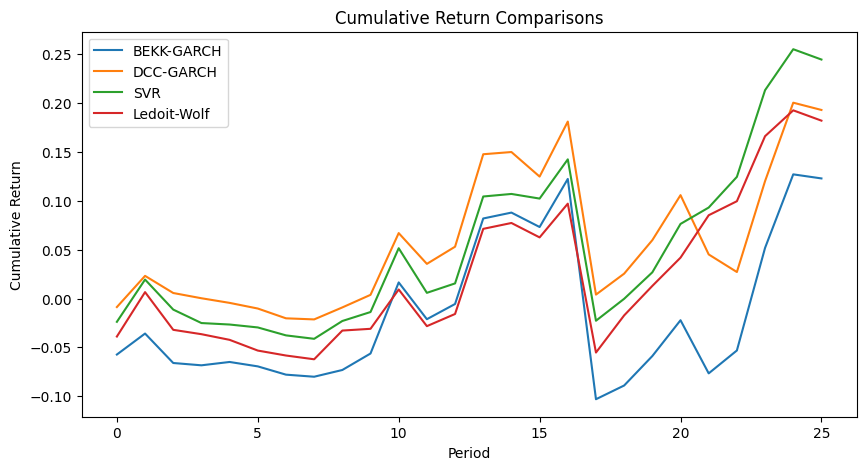

In [ ]:
import matplotlib.pyplot as plt

cum_bekk_port_r = (1 + bekk_port_r).cumprod() - 1
cum_dcc_port_r = (1 + dcc_port_r).cumprod() - 1
cum_svr_port_r = (1 + svr_port_r).cumprod() - 1
cum_lw_port_r = (1 + lw_port_r).cumprod() - 1
plt.figure(figsize=(10, 5))
plt.plot(cum_bekk_port_r, label='BEKK-GARCH')
plt.plot(cum_dcc_port_r, label='DCC-GARCH')
plt.plot(cum_svr_port_r, label='SVR')
plt.plot(cum_lw_port_r, label='Ledoit-Wolf') # Benchmark
plt.xlabel('Period')
plt.ylabel('Cumulative Return')
plt.title('Cumulative Return Comparisons')
plt.legend()
plt.grid(False)
plt.show()

In [303]:
eval_table = pd.DataFrame({
    "Models":['BEKK-GARCH', "DCC-GARCH", "SVR", "Ledoit Wolf"],
    "Frobenius Loss": [bekk_frob, dcc_frob, svr_frob, None],
    "Sharpe Ratio":[bekk_sr, dcc_sr, svr_sr, lw_sr],
    "Maximum Drawdown":[bekk_mdd, dcc_mdd, svr_mdd, lw_mdd]
}).sort_values(
    "Frobenius Loss",
    ascending=True,
    ignore_index=True
)
display(eval_table)

,Models,Frobenius Loss,Sharpe Ratio,Maximum Drawdown
0,SVR,0.000001,0.520384,-0.144601
1,DCC-GARCH,0.000002,0.341956,-0.149971
2,BEKK-GARCH,0.000002,0.133768,-0.200903
3,Ledoit Wolf,NaN,0.330297,-0.138924
